# S1 Backtest — Timing bake-off (IS)

Set **`N_STAR`** by hand from `01_n_grid_search` (suggested value printed there).
On **research IS only**, compare timing modes with **label-matched** prediction files:

| Mode | Enter | Exit | Weekend | Predictions |
|---|---|---|---|---|
| `mon_open_mon_open` | Monday open | Next Monday open | Held | `s1_linear_slim_ffill_is_predictions.parquet` (`fwd_ret_5`) |
| `mon_open_fri_close` | Monday open | Friday close | **Flat** (no weekend gap) | extras `s1_linear_slim_ffill_mon_fri_is_predictions.parquet` (`fwd_ret_mon_fri`) |

The notebook also prints a suggested **`TIMING_STAR`** (argmax IS net Sharpe).
Copy that string into `TIMING_STAR` in notebooks 03–06. OOS is not used here.

## Costs

Monday open one-way **15.5 bps**; Friday close one-way **10.5 bps** (lower slippage).

## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.report import plot_equity_overlay
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_FRI_CLOSE,
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)

PATHS = default_backtest_paths(ROOT)
ART = PATHS["artifacts"]
os.makedirs(ART, exist_ok=True)

# --- Set from notebook 01 (suggested N_STAR printed there) ---
N_STAR = 15

MODES = [TIMING_MON_OPEN_MON_OPEN, TIMING_MON_OPEN_FRI_CLOSE]
PRED_BY_MODE = {m: prediction_path_for_timing(PATHS, m) for m in MODES}

print(f"N_STAR={N_STAR} (notebook parameter — edit above)")
for mode, path in PRED_BY_MODE.items():
    print(f"  {mode}: {path}")
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15 (notebook parameter — edit above)
  mon_open_mon_open: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet
  mon_open_fri_close: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_tests\extras\s1_linear_slim_ffill_mon_fri_is_predictions.parquet


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Load scores & prices


In [2]:
bundles = {}
all_tickers: set[str] = set()
for mode in MODES:
    pred_path = PRED_BY_MODE[mode]
    preds = load_predictions(pred_path)
    scores = score_matrix(preds)
    is_mask = is_mask_from_preds(preds)
    bundles[mode] = {"scores": scores, "is_mask": is_mask, "pred_path": pred_path}
    all_tickers |= set(scores.columns)
    print(
        f"{mode}: scores={scores.shape}  IS dates={int(is_mask.sum())}  "
        f"file={os.path.basename(pred_path)}"
    )

opens, highs, lows, closes = load_ohlc_panels(
    PATHS["features"], tickers=list(all_tickers)
)
print(f"OHLC tickers={len(all_tickers)}  opens={opens.shape}")


mon_open_mon_open: scores=(592, 68)  IS dates=411  file=s1_linear_slim_ffill_is_predictions.parquet
mon_open_fri_close: scores=(592, 68)  IS dates=411  file=s1_linear_slim_ffill_mon_fri_is_predictions.parquet
OHLC tickers=68  opens=(4165, 68)


## 2. IS bake-off at N*


In [3]:
results = {}
rows = []
for mode in MODES:
    bundle = bundles[mode]
    res = run_backtest(
        bundle["scores"],
        opens,
        closes,
        n=N_STAR,
        timing_mode=mode,
        costs=DEFAULT_COSTS,
        date_mask=bundle["is_mask"],
    )
    results[mode] = res
    sm = summarize_periods(res.period_returns)
    sm_g = summarize_periods(res.period_returns_gross)
    rows.append(
        {
            "timing_mode": mode,
            "n": N_STAR,
            "predictions": os.path.basename(bundle["pred_path"]),
            "sharpe": sm["sharpe"],
            "cagr": sm["cagr"],
            "total_return": sm["total_return"],
            "max_drawdown": sm["max_drawdown"],
            "vol": sm["vol"],
            "win_rate": sm["win_rate"],
            "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
            "n_periods": sm["n_periods"],
            "sharpe_gross": sm_g["sharpe"],
            "total_return_gross": sm_g["total_return"],
        }
    )
    print(
        f"{mode}: sharpe={sm['sharpe']:.3f}  cagr={sm['cagr']:.3%}  "
        f"dd={sm['max_drawdown']:.3%}  turn={res.turnover.mean():.3f}  "
        f"preds={os.path.basename(bundle['pred_path'])}"
    )

bake_df = pd.DataFrame(rows).set_index("timing_mode")
display(bake_df)

best_mode = bake_df["sharpe"].idxmax()
TIMING_STAR = str(best_mode)
print(f"Suggested TIMING_STAR={TIMING_STAR}  (IS net Sharpe={bake_df.loc[TIMING_STAR, 'sharpe']:.4f})")
print("Copy this string into TIMING_STAR in notebooks 03–06.")


mon_open_mon_open: sharpe=0.765  cagr=7.016%  dd=-26.375%  turn=0.128  preds=s1_linear_slim_ffill_is_predictions.parquet
mon_open_fri_close: sharpe=-0.078  cagr=-0.985%  dd=-26.473%  turn=1.500  preds=s1_linear_slim_ffill_mon_fri_is_predictions.parquet


,n,predictions,sharpe,cagr,total_return,max_drawdown,vol,win_rate,mean_turnover,n_periods,sharpe_gross,total_return_gross
timing_mode,,,,,,,,,,,,
mon_open_mon_open,15,s1_linear_slim_ffill_is_predictions.parquet,0.765498,0.070164,0.706892,-0.263752,0.094487,0.592683,0.12813,410,0.874607,0.851468
mon_open_fri_close,15,s1_linear_slim_ffill_mon_fri_is_predictions.pa...,-0.077993,-0.009848,-0.075244,-0.264730,0.082947,0.535280,1.50000,411,1.066118,0.956892


Suggested TIMING_STAR=mon_open_mon_open  (IS net Sharpe=0.7655)
Copy this string into TIMING_STAR in notebooks 03–06.


## 3. Equity overlay


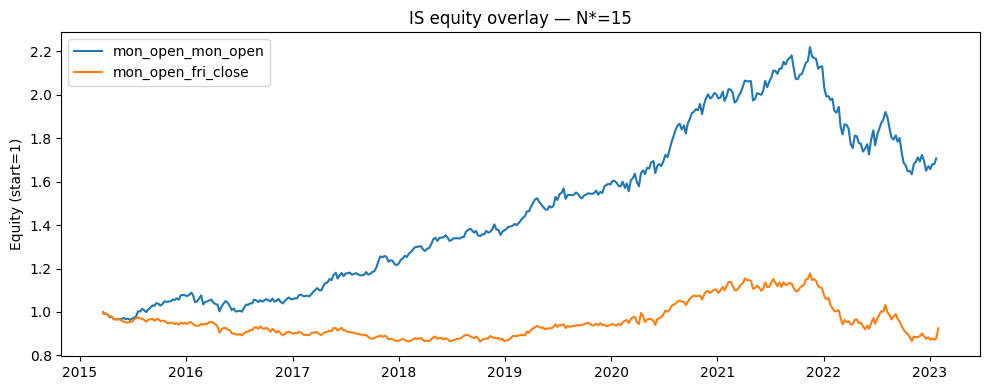

Gross weekend-gap residual (MonMon - MonFri) on 410 weeks: mean=0.00002  sharpe~=0.016
Suggested TIMING_STAR=mon_open_mon_open — set TIMING_STAR='mon_open_mon_open' in 03_weighting_bakeoff / 05_stop_bakeoff / 06_pct_stop_bakeoff / 07_oos_tearsheet


In [4]:
fig = plot_equity_overlay(
    {m: results[m].equity for m in MODES},
    title=f"IS equity overlay — N*={N_STAR}",
)
plt.show()

# Weekend-gap residual proxy: Mon→Mon return minus Mon→Fri return on overlapping entries
a = results[TIMING_MON_OPEN_MON_OPEN].period_returns_gross
b = results[TIMING_MON_OPEN_FRI_CLOSE].period_returns_gross
common = a.index.intersection(b.index)
gap = (a.reindex(common) - b.reindex(common)).dropna()
print(
    f"Gross weekend-gap residual (MonMon - MonFri) on {len(gap)} weeks: "
    f"mean={gap.mean():.5f}  sharpe~={(gap.mean()/gap.std()*np.sqrt(52)) if gap.std()>0 else np.nan:.3f}"
)

print(f"Suggested TIMING_STAR={TIMING_STAR} — set TIMING_STAR={TIMING_STAR!r} in 03_weighting_bakeoff / 05_stop_bakeoff / 06_pct_stop_bakeoff / 08_oos_tearsheet")
